In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

2026-03-05 16:50:40.058464: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def build_tiny_autoencoder(input_shape=(64, 64, 1)):
    # --- ENCODER ---
    input_img = layers.Input(shape=input_shape)
    
    # Layer 1: Captures basic edges/rhythms
    # Using 8 filters keeps DSP usage low
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Down to 32x32
    
    # Layer 2: Deeper features
    x = layers.Conv2D(4, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Down to 16x16
    
    # Latent Space (The DNA of the sound)
    # Flattening to a small vector (e.g., 128 elements)
    shape_before_flattening = tf.keras.backend.int_shape(x)[1:]
    x = layers.Flatten()(x)
    latent_space = layers.Dense(32, name="latent_space")(x) 
    
    # --- DECODER ---
    dense_shape = np.prod([s for s in shape_before_flattening])
    x = layers.Dense(dense_shape)(latent_space)
    x = layers.Reshape(shape_before_flattening)(x)
    
    x = layers.Conv2DTranspose(4, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2DTranspose(8, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    return models.Model(input_img, decoded)

autoencoder = build_tiny_autoencoder()
autoencoder.compile(optimizer='adam', loss='mae') # MAE is better for anomaly detection

2026-03-05 16:50:47.058282: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (100)


In [16]:
def spectrogram_to_tensor(spectrogram, window_size=64, step_size=32):
    # We want to create windows of 64x64
    n_mels, steps = spectrogram.shape
    windows = []
    for start in range(0, steps - window_size + 1, step_size):
            window = spectrogram[:, start : start + window_size]
            windows.append(window)
    
    X = np.array(windows)
    X = np.expand_dims(X, axis=-1)
    return X

def create_dataset(data_dir, file = None, window_size=64, step_size=32):
    all_windows = []
    if file is not None:
        files = [file]
    else:
        files = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
    
    for f in files:
        spec = np.load(os.path.join(data_dir, f))
        
        all_windows.append(spectrogram_to_tensor(spec, window_size, step_size))

    X = np.concatenate(all_windows, axis=0)
    np.random.shuffle(X)
    return X

X_train = create_dataset('../data/spectrogram/normal/')

# 2. Split for validation (keep 20% back to check for overfitting)
split = int(0.8 * len(X_train))
train_data = X_train[:split]
val_data = X_train[split:]

print(f"Total training windows: {len(train_data)}")

# 3. Train
# In autoencoders, x and y are the same!
history = autoencoder.fit(
    train_data, train_data,
    epochs=50,
    batch_size=32,
    validation_data=(val_data, val_data),
    shuffle=True
)

Total training windows: 6835
Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0368 - val_loss: 0.0364
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0367 - val_loss: 0.0365
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0367 - val_loss: 0.0365
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0367 - val_loss: 0.0364
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0366 - val_loss: 0.0364
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0366 - val_loss: 0.0363
Epoch 7/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0366 - val_loss: 0.0363
Epoch 8/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0366 - val_loss: 0.0365
Epoch 9/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0365 - val_loss: 0.0363
Epoch 10/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0365 - val_loss: 0.0363
Epoch 11/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0364 - val_loss: 0.0364
E

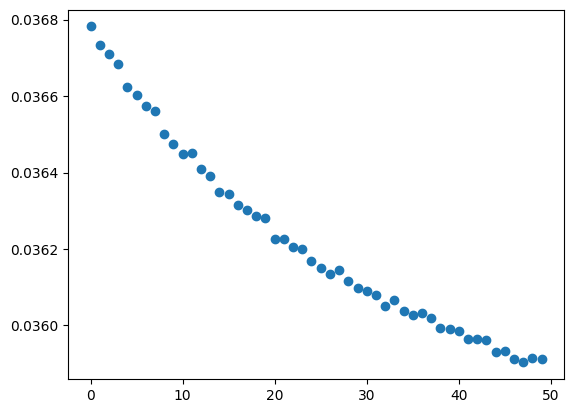

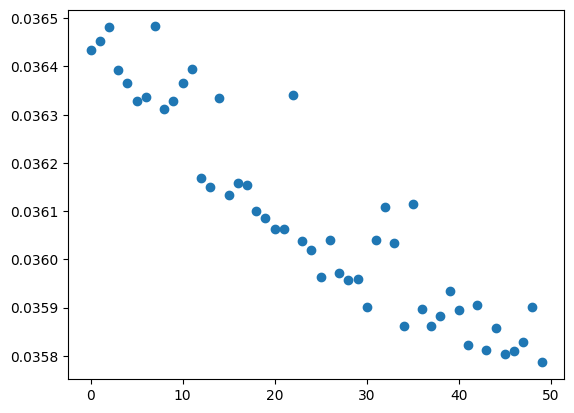

In [17]:
plt.scatter(range(len(history.history['loss'])), history.history['loss'], label='Train Loss')
plt.figure()
plt.scatter(range(len(history.history['val_loss'])), history.history['val_loss'], label='Validation Loss')

In [18]:
autoencoder.save('3d_printer_anomaly_model.keras')

In [21]:
%run audio.ipynb

def detect_anomalies(file_path, model, threshold=0.05):
    # 1. Prep the spectrogram
    spec = generate_fpga_style_spectrogram(file_path) # (64, 313)
    
    # 2. Slice into windows (Batch, 64, 64, 1)
    windows = spectrogram_to_tensor(spec) 
    print(f"Windows Shape: {windows.shape}")
    
    # 3. Model "tries" to reconstruct the sound
    reconstructed = model.predict(windows)
    
    # 4. Calculate error per window
    # Shape of 'errors' will be (Number_of_Windows,)
    errors = np.mean(np.abs(windows - reconstructed), axis=(1, 2, 3))
    
    # 5. Identify which windows are bad
    anomalous_indices = np.where(errors > threshold)[0]
    
    return errors, anomalous_indices

In [29]:
detect_anomalies('../-6_dB_slider/slider/id_00/abnormal/00000011.wav', autoencoder)

Windows Shape: (8, 64, 64, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


(array([0.0407382 , 0.04183278, 0.04166625, 0.04128409, 0.04717011,
        0.05383094, 0.0500127 , 0.05092914], dtype=float32),
 array([5, 6, 7]))